# Biomedical Insurance Cost Predictor (Traditional Machine Learning) - Insurance dataset

### 1) Import Libraries

In [1]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data/insurance_dataset"

#----- Tools, visualizers -----
from utils import *
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

#----- Preprocessing -----
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

#----- Models -----
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso,\
      ElasticNet, RANSACRegressor, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,\
      AdaBoostRegressor, ExtraTreesRegressor

#----- Variables -----
RANDOM_STATE = 42



### 2) Load Data

In [2]:
# Load train set
#---------------
data = pd.read_csv(DATA_DIR / "insurance_train_set.csv")
test = pd.read_csv(DATA_DIR / "insurance_test_set.csv")

data.shape, test.shape

((1137, 7), (201, 7))

#### About handling invalid values
Since the dataset at hand is already clean and there are no missing & invalid values, We do not perform this stage in this notebook.

### 3) Define feature columns and target 
> Target: charges

In [3]:
"""
Separate features and target for the regression task.

- Target: `charges`
- Features: all columns except `charges`

"""

# -------------------------------------
# charges as the target
# -------------------------------------

# ---------- DATA ---------

# Separate features and labels cols
X_TRAIN = data.drop(columns=['charges']) # Features
y_train = data['charges'] # Labels


# ---------- TEST ---------

# Separate features and labels cols
X_TEST = test.drop(columns=['charges']) # Features
y_test = test['charges'] # Labels


# Display shapes
print("----- DONE -----", end='\n\n')
print(f"Shapes:\n\nX_TRAIN: {X_TRAIN.shape} | y_train: {y_train.shape}")
print(f"X_TEST: {X_TEST.shape} | y_test: {y_test.shape}")


----- DONE -----

Shapes:

X_TRAIN: (1137, 6) | y_train: (1137,)
X_TEST: (201, 6) | y_test: (201,)


In [4]:
print("smoker:", X_TRAIN['smoker'].unique())
print("sex:", X_TRAIN['sex'].unique())
print("region:", X_TRAIN['region'].unique())

smoker: <StringArray>
['yes', 'no']
Length: 2, dtype: str
sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
region: <StringArray>
['northwest', 'southeast', 'southwest', 'northeast']
Length: 4, dtype: str


### 4) Core Feature Engineering

#### 1- Feature columns (except target)

In [5]:

# Experiment 1
def smoking_interaction_features(X):
    # Make a copy of X
    x = X.copy()

    # Binarize smoker col - Temporary
    smoker_num = x['smoker'].map({'no': 0, 'yes': 1}) 

    # Build obesity feature that's needed for high_risk feature - temporary
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)

    # Build smoker related features
    x['bmi_smoker'] = x['bmi'] * smoker_num
    x['age_smoker'] = x['age'] * smoker_num
    x['high_risk'] = x['obesity'] * smoker_num

    # Drop obesity col
    x.drop(columns=['obesity'], inplace=True)

    return x

# Expriment 2
def bmi_age_related_features(X):
    # Make a copy of X
    x = X.copy()

    # Build bmi/age related features
    x['bmi_age'] = x['age'] * x['bmi']
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)
    x['severe_obesity'] = np.where(x['bmi'] >= 35, 1, 0)

    return x

# Experiment 3
def all_eng_featured_combined(X):
    # Make a copy of X
    x = X.copy()

    # Binarize smoker col - Temporary
    smoker_num = x['smoker'].map({'no': 0, 'yes': 1})

    # Build bmi/age related features
    x['bmi_age'] = x['age'] * x['bmi']
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)
    x['severe_obesity'] = np.where(x['bmi'] >= 35, 1, 0)

    # Build smoker related features
    x['bmi_smoker'] = x['bmi'] * smoker_num
    x['age_smoker'] = x['age'] * smoker_num
    x['high_risk'] = x['obesity'] * smoker_num

    return x


# Apply smoker related eng
x_smoker_train = smoking_interaction_features(X_TRAIN)
x_smoker_test = smoking_interaction_features(X_TEST)

# Apply bmi/age related eng
x_bmi_age_train = bmi_age_related_features(X_TRAIN)
x_bmi_age_test = bmi_age_related_features(X_TEST)

# Apply all features eng
x_all_train = all_eng_featured_combined(X_TRAIN)
x_all_test = all_eng_featured_combined(X_TEST)


print("----- Feature Engineering Done -----")


----- Feature Engineering Done -----


In [6]:
# Check basekine
X_TRAIN.head(5)

,age,sex,bmi,children,smoker,region
0,52,male,27.360,0,yes,northwest
1,30,male,44.220,2,no,southeast
2,19,male,27.265,2,no,northwest
3,20,female,26.840,1,yes,southeast
4,27,female,24.750,0,yes,southeast


In [7]:
# Check ex1
x_smoker_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_smoker,age_smoker,high_risk
0,52,male,27.360,0,yes,northwest,27.36,52,0
1,30,male,44.220,2,no,southeast,0.00,0,0
2,19,male,27.265,2,no,northwest,0.00,0,0
3,20,female,26.840,1,yes,southeast,26.84,20,0
4,27,female,24.750,0,yes,southeast,24.75,27,0


In [74]:
# Check ex2
x_bmi_age_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_age,obesity,severe_obesity
0,52,male,27.360,0,yes,northwest,1422.720,0,0
1,30,male,44.220,2,no,southeast,1326.600,1,1
2,19,male,27.265,2,no,northwest,518.035,0,0
3,20,female,26.840,1,yes,southeast,536.800,0,0
4,27,female,24.750,0,yes,southeast,668.250,0,0


In [75]:
# Check ex3
x_all_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_age,obesity,severe_obesity,bmi_smoker,age_smoker,high_risk
0,52,male,27.360,0,yes,northwest,1422.720,0,0,27.36,52,0
1,30,male,44.220,2,no,southeast,1326.600,1,1,0.00,0,0
2,19,male,27.265,2,no,northwest,518.035,0,0,0.00,0,0
3,20,female,26.840,1,yes,southeast,536.800,0,0,26.84,20,0
4,27,female,24.750,0,yes,southeast,668.250,0,0,24.75,27,0


##### -  A quick sanity check and EDA for new features

In [8]:
all_new_num = ['bmi_smoker', 'age_smoker', 'bmi_age']

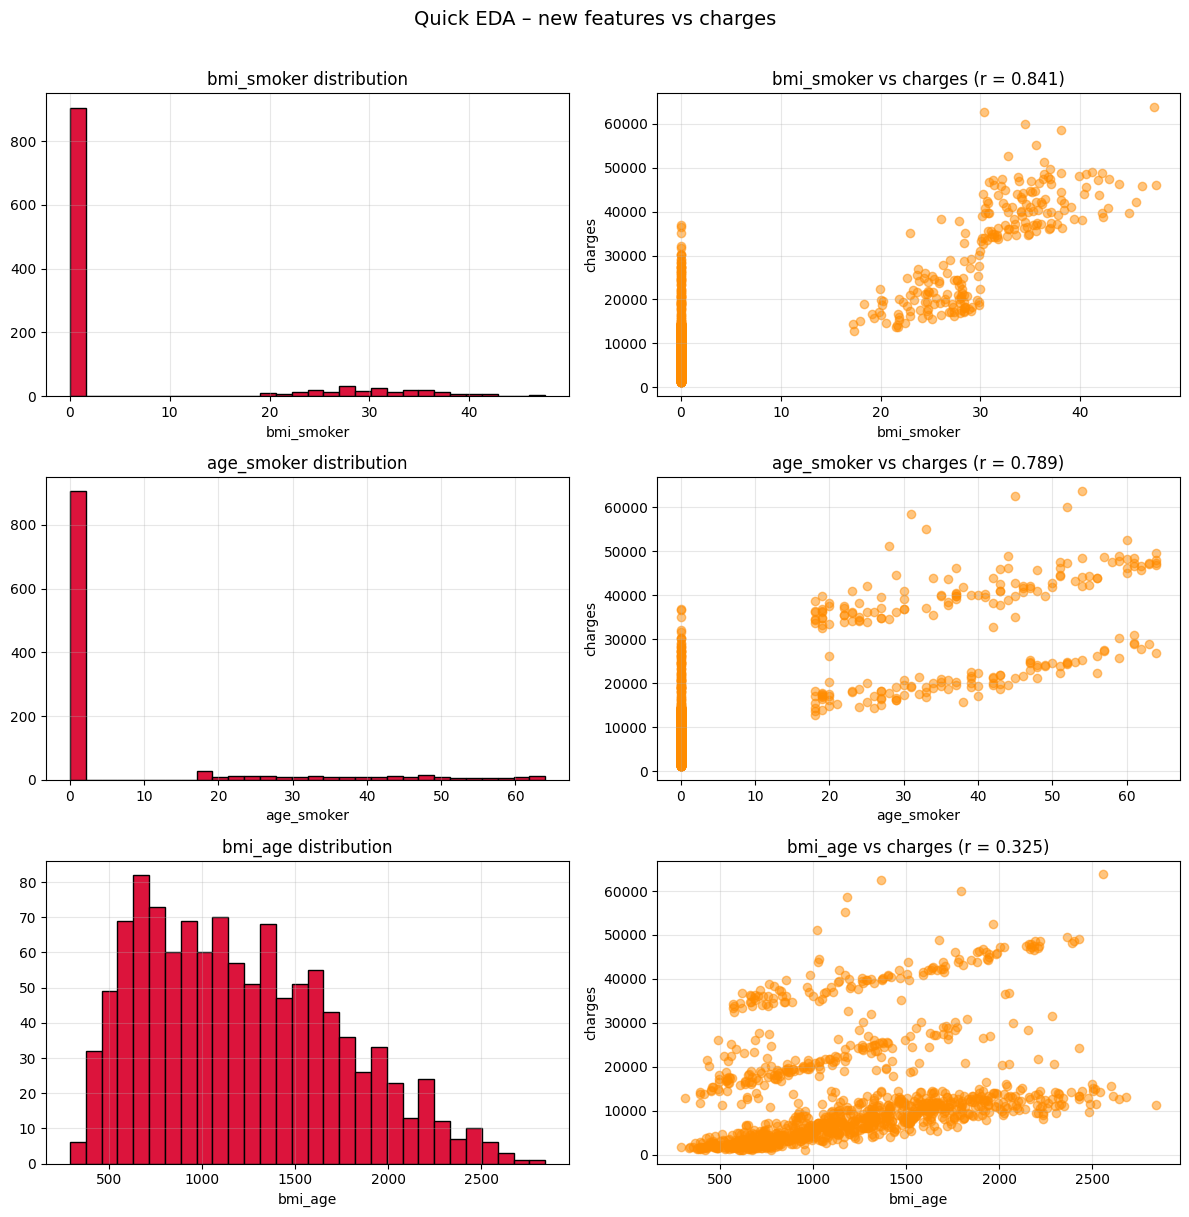

In [60]:
# Quick EDA on the numeric features
# ---------------------------------------------
def plot_features_eda(X, y, features, target_name, hist_c, scat_c, ncols=2):
    """
    For each feature in `features`, create a row with two subplots:
    histogram of the feature (left) and scatter vs target (right).
    """
    nrows = len(features)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    
    # Make sure axes is 2D even for a single row
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    for i, feat in enumerate(features):
        r, _ = scipy.stats.pearsonr(X[feat], y)
        
        # Histogram
        axes[i, 0].hist(X[feat], bins=30, color=hist_c, edgecolor='k')
        axes[i, 0].set_title(f'{feat} distribution')
        axes[i, 0].set_xlabel(feat)
        axes[i, 0].grid(alpha=0.3)
        
        # Scatter
        axes[i, 1].scatter(X[feat], y, alpha=0.5, color=scat_c)
        axes[i, 1].set_title(f'{feat} vs {target_name} (r = {r:.3f})')
        axes[i, 1].set_xlabel(feat)
        axes[i, 1].set_ylabel(target_name)
        axes[i, 1].grid(alpha=0.3)
    
    plt.suptitle(f'Quick EDA – new features vs {target_name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_features_eda(x_all_train, y_train, all_new_num,
                  'charges', 'crimson', 'darkorange')



In [9]:
all_new_cat = ['obesity', 'severe_obesity', 'high_risk']

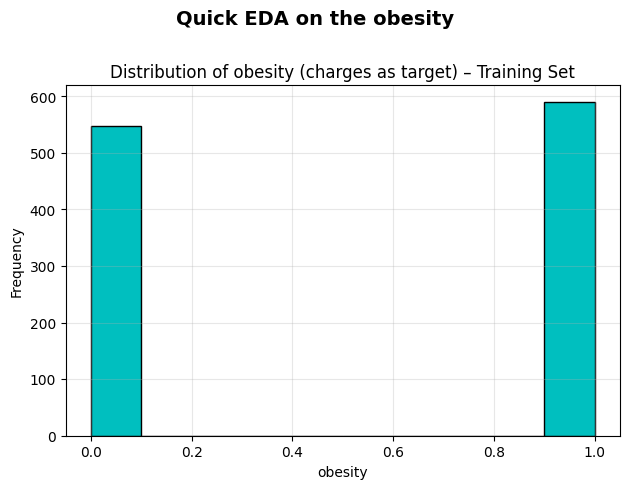

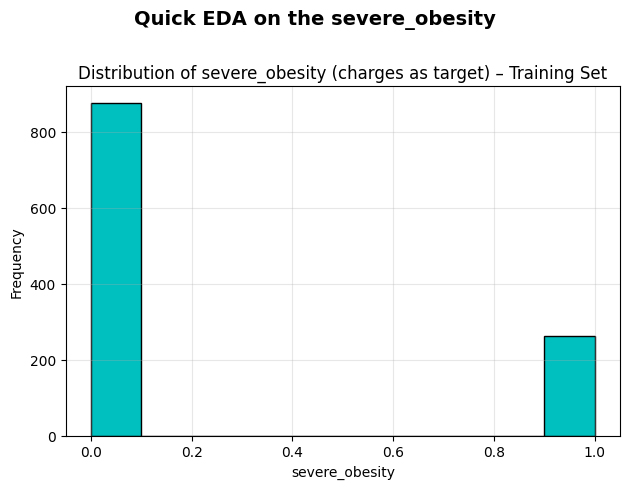

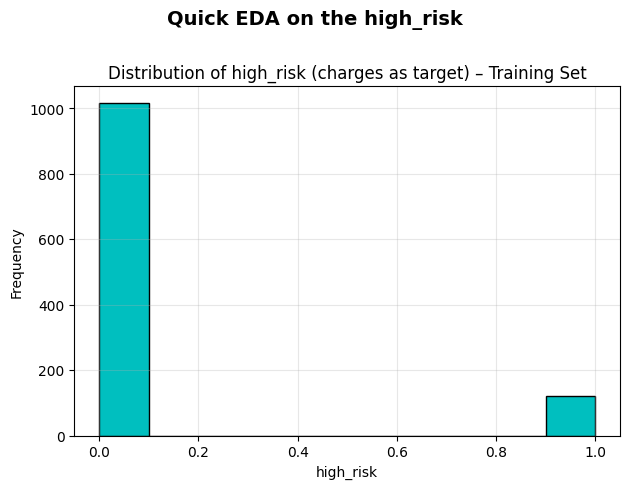

In [49]:
def plot_cat_dis(X, feat):
    # Histogram of new cat features (training set)
    X[feat].hist(color='c', edgecolor='k')
    plt.title(f'Distribution of {feat} (charges as target) – Training Set')
    plt.xlabel(feat)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)


    plt.suptitle(f"Quick EDA on the {feat}", fontsize=14, weight='bold' ,y=1.01)
    plt.tight_layout()
    plt.show()


for f in all_new_cat:
    plot_cat_dis(x_all_train, f)

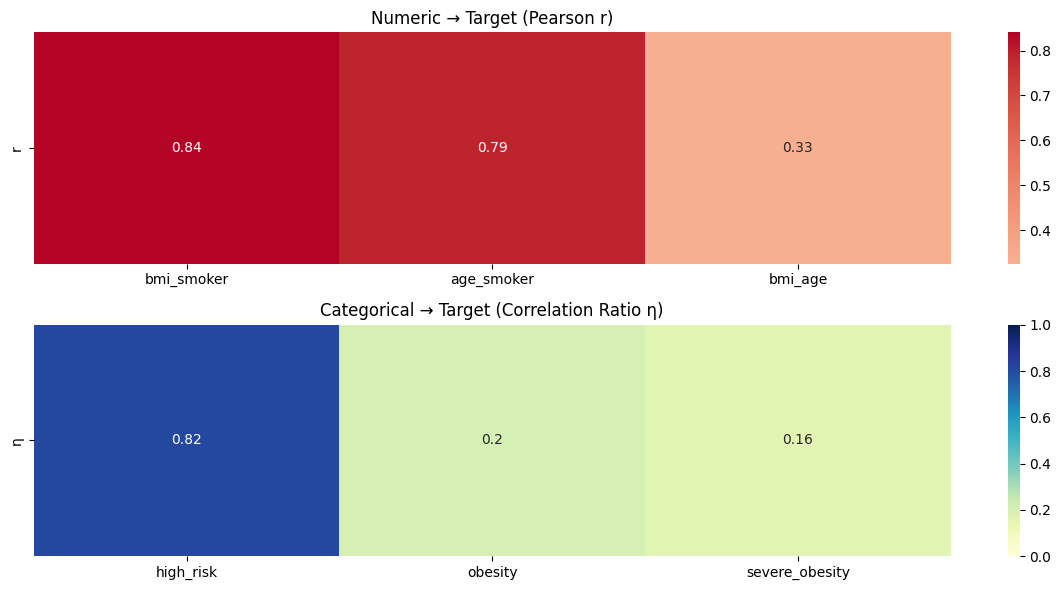

In [50]:
full_train_ana = x_all_train.copy()
full_train_ana['charges'] = y_train.values

# Now pass them to the analyzer
analyzer_all = CorrelationAnalyzer(
    data=full_train_ana,
    target_type='numeric',
    num_cols=all_new_num,
    cat_cols=all_new_cat,
    target_col='charges'
)

analyzer_all.plot_feature_numeric_target()

#### 2- Target column
- We'll apply log-transformer on the target to address it being right-skewed. 
- The difference of applying this technique is analyzed and showcased in the `EDA notebook`. 

In [10]:
# Raw targets
y_train_raw = y_train.values
y_test_raw = y_test.values

# Log targets
y_train_log = np.log1p(y_train.values)
y_test_log = np.log1p(y_test.values)

### 5) Core of preprocessing and handling data


In [11]:
"""
"Children was treated as a numerical count variable,
 while sex and Smoking were treated as a binary categorical variable and
 region was encoded using one-hot encoding."
"""

# =====================================================
# Feature Groups
# =====================================================

# ----- Baseline -----

baseline_num_features = ['age', 'bmi', 'children']
baseline_bin_features = ['sex', 'smoker']
baseline_nom_features = ['region']


# ----- Smoker Engineering -----

smoker_num_features = baseline_num_features + ['bmi_smoker', 'age_smoker']
smoker_bin_features = baseline_bin_features + ['high_risk']


# ----- BMI / Age Engineering -----

bmi_age_num_features = baseline_num_features + ['bmi_age']
bmi_age_bin_features = baseline_bin_features + ['obesity', 'severe_obesity']


# ----- All Engineered Features -----

all_eng_num_features = baseline_num_features + ['bmi_age', 'bmi_smoker', 'age_smoker']
all_eng_bin_features = baseline_bin_features + ['obesity', 'severe_obesity', 'high_risk']


# Pipelines
#----------------

# Continuous numeric feat
con_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Binary feat
bin_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

# Nominal feat
nom_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


# Combine all Pipelines to build the full preprocessors
#------------------------------------------------------

# --- Baseline ---
preprocessor_baseline = ColumnTransformer([
    ("num", con_num_pipeline, baseline_num_features),
    ("bin", bin_pipeline, baseline_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- Smoker eng ---
preprocessor_smoker = ColumnTransformer([
    ("num", con_num_pipeline, smoker_num_features),
    ("bin", bin_pipeline, smoker_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- BMI / Age eng ---
preprocessor_bmi_age = ColumnTransformer([
    ("num", con_num_pipeline, bmi_age_num_features),
    ("bin", bin_pipeline, bmi_age_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- All eng ---
preprocessor_all = ColumnTransformer([
    ("num", con_num_pipeline, all_eng_num_features),
    ("bin", bin_pipeline, all_eng_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])


print("----- Preprocessing Pipelines Ready -----")

----- Preprocessing Pipelines Ready -----


####  - Fit on the full training data and transform  

In [12]:
# Baseline
#-----------------------------

# Fit on the entire training set 
preprocessor_baseline.fit(X_TRAIN)

# Transform both training and test sets
X_train_prep_baseline = preprocessor_baseline.transform(X_TRAIN).astype(np.float32)
X_test_prep_baseline  = preprocessor_baseline.transform(X_TEST).astype(np.float32)

print("Baseline:")
print("X_train_prep shape:", X_train_prep_baseline.shape)
print("X_test_prep shape:",  X_test_prep_baseline.shape)

Baseline:
X_train_prep shape: (1137, 9)
X_test_prep shape: (201, 9)


In [13]:
# Smoker
#-----------------------------

# Fit on the entire training set 
preprocessor_smoker.fit(x_smoker_train)

# Transform both training and test sets
X_train_prep_smoker = preprocessor_smoker.transform(x_smoker_train).astype(np.float32)
X_test_prep_smoker  = preprocessor_smoker.transform(x_smoker_test).astype(np.float32)

print("Smoker Eng:")
print("X_train_prep shape:", X_train_prep_smoker.shape)
print("X_test_prep shape:",  X_test_prep_smoker.shape)

Smoker Eng:
X_train_prep shape: (1137, 12)
X_test_prep shape: (201, 12)


In [14]:
# BMI / Age
#-----------------------------

# Fit on the entire training set 
preprocessor_bmi_age.fit(x_bmi_age_train)

# Transform both training and test sets
X_train_prep_bmi_age = preprocessor_bmi_age.transform(x_bmi_age_train).astype(np.float32)
X_test_prep_bmi_age  = preprocessor_bmi_age.transform(x_bmi_age_test).astype(np.float32)

print("BMI / Age Eng:")
print("X_train_prep shape:", X_train_prep_bmi_age.shape)
print("X_test_prep shape:",  X_test_prep_bmi_age.shape)

BMI / Age Eng:
X_train_prep shape: (1137, 12)
X_test_prep shape: (201, 12)


In [15]:
# All 
#-----------------------------

# Fit on the entire training set 
preprocessor_all.fit(x_all_train)

# Transform both training and test sets
X_train_prep_all = preprocessor_all.transform(x_all_train).astype(np.float32)
X_test_prep_all  = preprocessor_all.transform(x_all_test).astype(np.float32)

print("All Eng:")
print("X_train_prep shape:", X_train_prep_all.shape)
print("X_test_prep shape:",  X_test_prep_all.shape)

All Eng:
X_train_prep shape: (1137, 15)
X_test_prep shape: (201, 15)


In [16]:
# columns check
feature_names = preprocessor_baseline.get_feature_names_out()

print(len(feature_names))
print(feature_names)

9
['num__age' 'num__bmi' 'num__children' 'bin__sex' 'bin__smoker'
 'nom__region_northeast' 'nom__region_northwest' 'nom__region_southeast'
 'nom__region_southwest']


In [17]:
# NaNs check
print(np.isnan(X_train_prep_baseline).sum())
print(np.isnan(X_train_prep_smoker).sum())
print(np.isnan(X_train_prep_bmi_age).sum())
print(np.isnan(X_train_prep_all).sum())

0
0
0
0


### 6) Model Benchmarking

In [18]:
# Initialize the models
models = {
    'AdaBoost Regressor': AdaBoostRegressor(random_state=RANDOM_STATE),
    'Extra Trees Regressor': ExtraTreesRegressor(random_state=RANDOM_STATE),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Random Forest Regressor': RandomForestRegressor(random_state=RANDOM_STATE),
    'Elastic Net': ElasticNet(random_state=RANDOM_STATE),
    'RANSAC Regressor': RANSACRegressor(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Gaussian Process Regressor': GaussianProcessRegressor(random_state=RANDOM_STATE),
    'Linear Regression': LinearRegression(),
    'Huber Regressor': HuberRegressor(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'SVR': SVR()
}


# Scoring metrics: we'll compute RMSE manually from neg_mean_squared_error, and use r2 directly
scoring = {
    'R2': 'r2'
    #'RMSE': 'neg_root_mean_squared_error',
    #'MAE': 'neg_mean_absolute_error'
}

def model_benchmark(models, X, y, scoring):
    # Cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results = []

    for name, model in models.items():
        regressor = clone(model)

        # cross_validate
        cv_results = cross_validate(
            regressor, X, y,
            cv=cv, scoring=scoring,
            return_train_score=False, n_jobs=-1
        )
        
        # Extract mean and std of each metric
        r2_mean   =  cv_results['test_R2'].mean()
        r2_std    =  cv_results['test_R2'].std()

        results.append({
            "Model": name,
            "R2_mean": r2_mean,
            "R2_std": r2_std
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    # Sort by R² descending
    results_df = results_df.sort_values(by='R2_mean', ascending=False).reset_index(drop=True)
    return results_df



In [19]:
#===========================
# Apply on the RAW TARGET
#===========================
baseline_results_raw = model_benchmark(models, X_train_prep_baseline, y_train_raw, scoring)
smoker_results_raw = model_benchmark(models, X_train_prep_smoker, y_train_raw, scoring)
bmi_age_results_raw = model_benchmark(models, X_train_prep_bmi_age, y_train_raw, scoring)
all_eng_results_raw = model_benchmark(models, X_train_prep_all, y_train_raw, scoring)


print('----- Benchmarking results on the RAW TARGET saved -----')

----- Benchmarking results on the RAW TARGET saved -----


In [20]:
#===========================
# Apply on the LOG TARGET
#===========================
baseline_results_log = model_benchmark(models, X_train_prep_baseline, y_train_log, scoring)
smoker_results_log = model_benchmark(models, X_train_prep_smoker, y_train_log, scoring)
bmi_age_results_log = model_benchmark(models, X_train_prep_bmi_age, y_train_log, scoring)
all_eng_results_log = model_benchmark(models, X_train_prep_all, y_train_log, scoring)


print('----- Benchmarking results on the LOG TARGET saved -----')

----- Benchmarking results on the LOG TARGET saved -----


#### - Results on the RAW TARGET for 4 training sets

In [91]:
baseline_results_raw

,Model,R2_mean,R2_std
0,Gradient Boosting Regressor,0.851388,0.015539
1,Random Forest Regressor,0.836725,0.009350
2,Extra Trees Regressor,0.825392,0.008328
3,AdaBoost Regressor,0.813755,0.028896
4,Ridge,0.733703,0.019659
5,Lasso,0.733696,0.020053
6,Linear Regression,0.733675,0.020058
7,Decision Tree Regressor,0.700791,0.049861
8,Huber Regressor,0.652041,0.049348
9,K-Neighbors Regressor,0.620465,0.030713


In [92]:
smoker_results_raw

,Model,R2_mean,R2_std
0,Lasso,0.863973,0.021276
1,Linear Regression,0.863934,0.021267
2,Ridge,0.863863,0.021392
3,Huber Regressor,0.854135,0.025675
4,RANSAC Regressor,0.853451,0.025499
5,Gradient Boosting Regressor,0.847793,0.017226
6,Random Forest Regressor,0.836880,0.012165
7,K-Neighbors Regressor,0.829898,0.021742
8,Extra Trees Regressor,0.828765,0.007821
9,Elastic Net,0.762023,0.014063


In [93]:
bmi_age_results_raw

,Model,R2_mean,R2_std
0,Gradient Boosting Regressor,0.852617,0.019046
1,Random Forest Regressor,0.838141,0.012048
2,Extra Trees Regressor,0.828297,0.009934
3,AdaBoost Regressor,0.809354,0.007278
4,Lasso,0.739142,0.020048
5,Ridge,0.739114,0.019554
6,Linear Regression,0.739072,0.020037
7,Decision Tree Regressor,0.692688,0.035146
8,Huber Regressor,0.657002,0.047896
9,RANSAC Regressor,0.552770,0.056647


In [21]:
all_eng_results_raw

,Model,R2_mean,R2_std
0,Lasso,0.863431,0.021264
1,Linear Regression,0.863354,0.021259
2,Ridge,0.863332,0.021358
3,Huber Regressor,0.854195,0.025575
4,RANSAC Regressor,0.853669,0.025493
5,Gradient Boosting Regressor,0.849596,0.017004
6,Random Forest Regressor,0.837942,0.012042
7,K-Neighbors Regressor,0.837274,0.018117
8,Extra Trees Regressor,0.831442,0.009967
9,Elastic Net,0.767429,0.012543


#### - Results on the LOG TARGET for 4 training sets

In [95]:
baseline_results_log

,Model,R2_mean,R2_std
0,Gradient Boosting Regressor,0.823321,0.017838
1,SVR,0.819263,0.021855
2,Random Forest Regressor,0.813317,0.018922
3,Extra Trees Regressor,0.791305,0.020812
4,Linear Regression,0.754068,0.014063
5,Ridge,0.754058,0.013894
6,Huber Regressor,0.739601,0.021868
7,AdaBoost Regressor,0.727655,0.045208
8,RANSAC Regressor,0.726204,0.026309
9,Decision Tree Regressor,0.688124,0.022966


In [96]:
smoker_results_log

,Model,R2_mean,R2_std
0,SVR,0.829556,0.024689
1,Gradient Boosting Regressor,0.825287,0.018342
2,Linear Regression,0.819409,0.022884
3,Ridge,0.818394,0.023318
4,Huber Regressor,0.813461,0.027110
5,Random Forest Regressor,0.812672,0.019403
6,RANSAC Regressor,0.804945,0.027406
7,Extra Trees Regressor,0.790571,0.020703
8,K-Neighbors Regressor,0.788330,0.016624
9,AdaBoost Regressor,0.720850,0.039214


In [97]:
bmi_age_results_log

,Model,R2_mean,R2_std
0,SVR,0.824170,0.022653
1,Gradient Boosting Regressor,0.821661,0.017790
2,Random Forest Regressor,0.811754,0.019152
3,Extra Trees Regressor,0.790655,0.013832
4,Ridge,0.753940,0.014522
5,Linear Regression,0.753938,0.014867
6,Huber Regressor,0.741327,0.021422
7,AdaBoost Regressor,0.706125,0.043060
8,RANSAC Regressor,0.700374,0.050328
9,Decision Tree Regressor,0.683977,0.032934


In [22]:
all_eng_results_log

,Model,R2_mean,R2_std
0,SVR,0.830076,0.024937
1,Gradient Boosting Regressor,0.820227,0.022520
2,Linear Regression,0.818310,0.023043
3,Ridge,0.817388,0.023907
4,Huber Regressor,0.813348,0.027241
5,Random Forest Regressor,0.810785,0.020311
6,RANSAC Regressor,0.805090,0.028059
7,Extra Trees Regressor,0.793103,0.014716
8,K-Neighbors Regressor,0.789730,0.017339
9,AdaBoost Regressor,0.720183,0.030000


#### - The results of benchmarking visualized

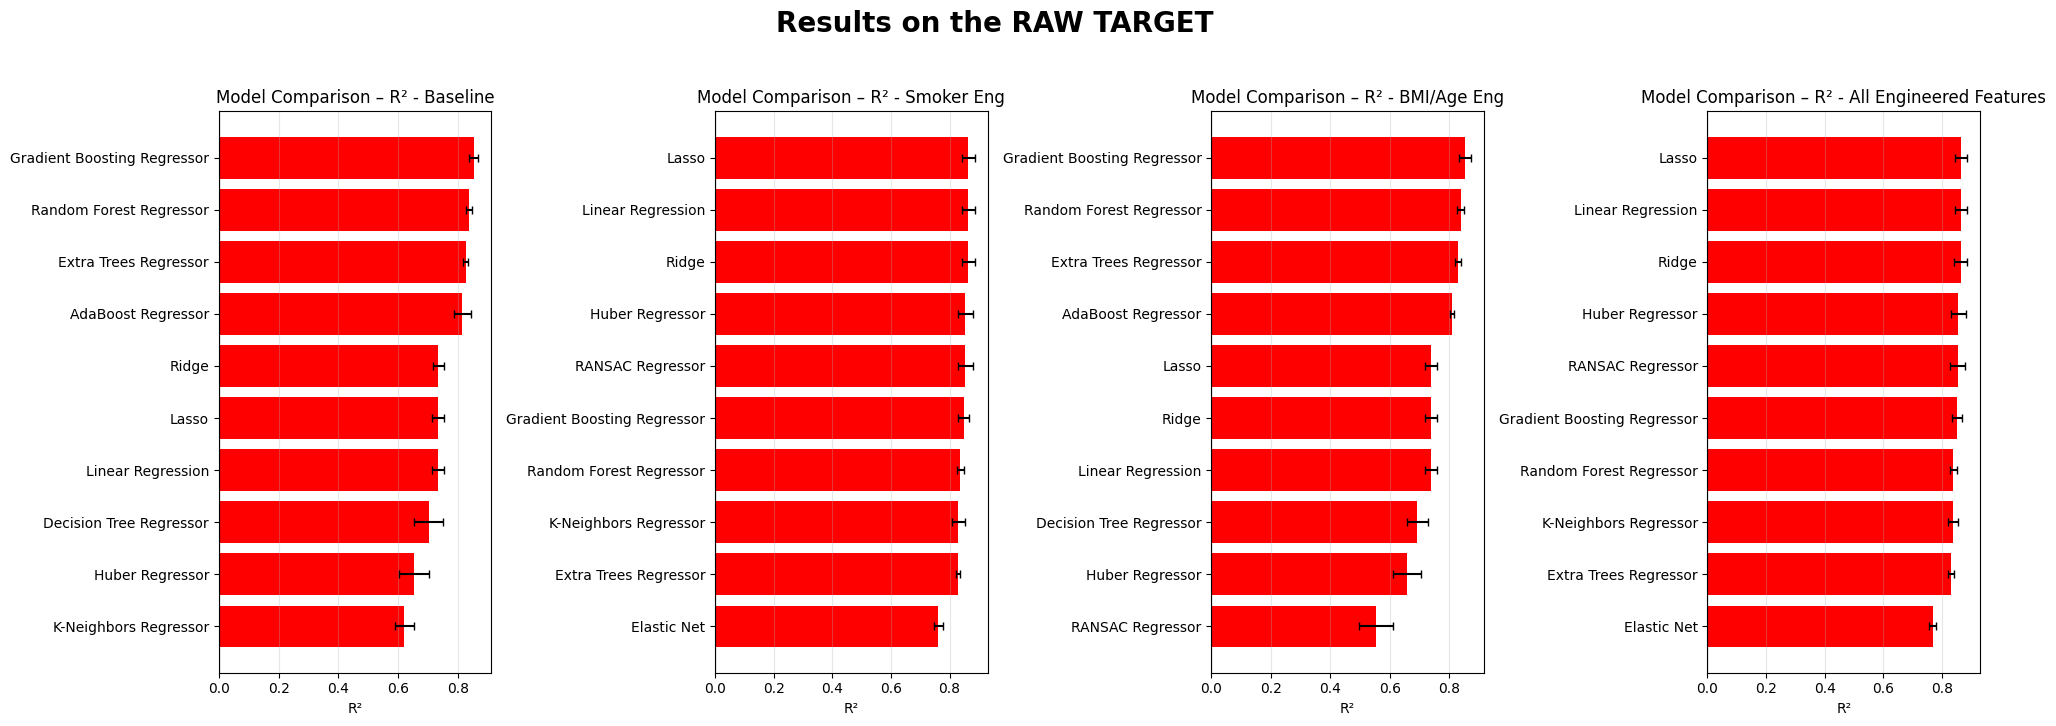

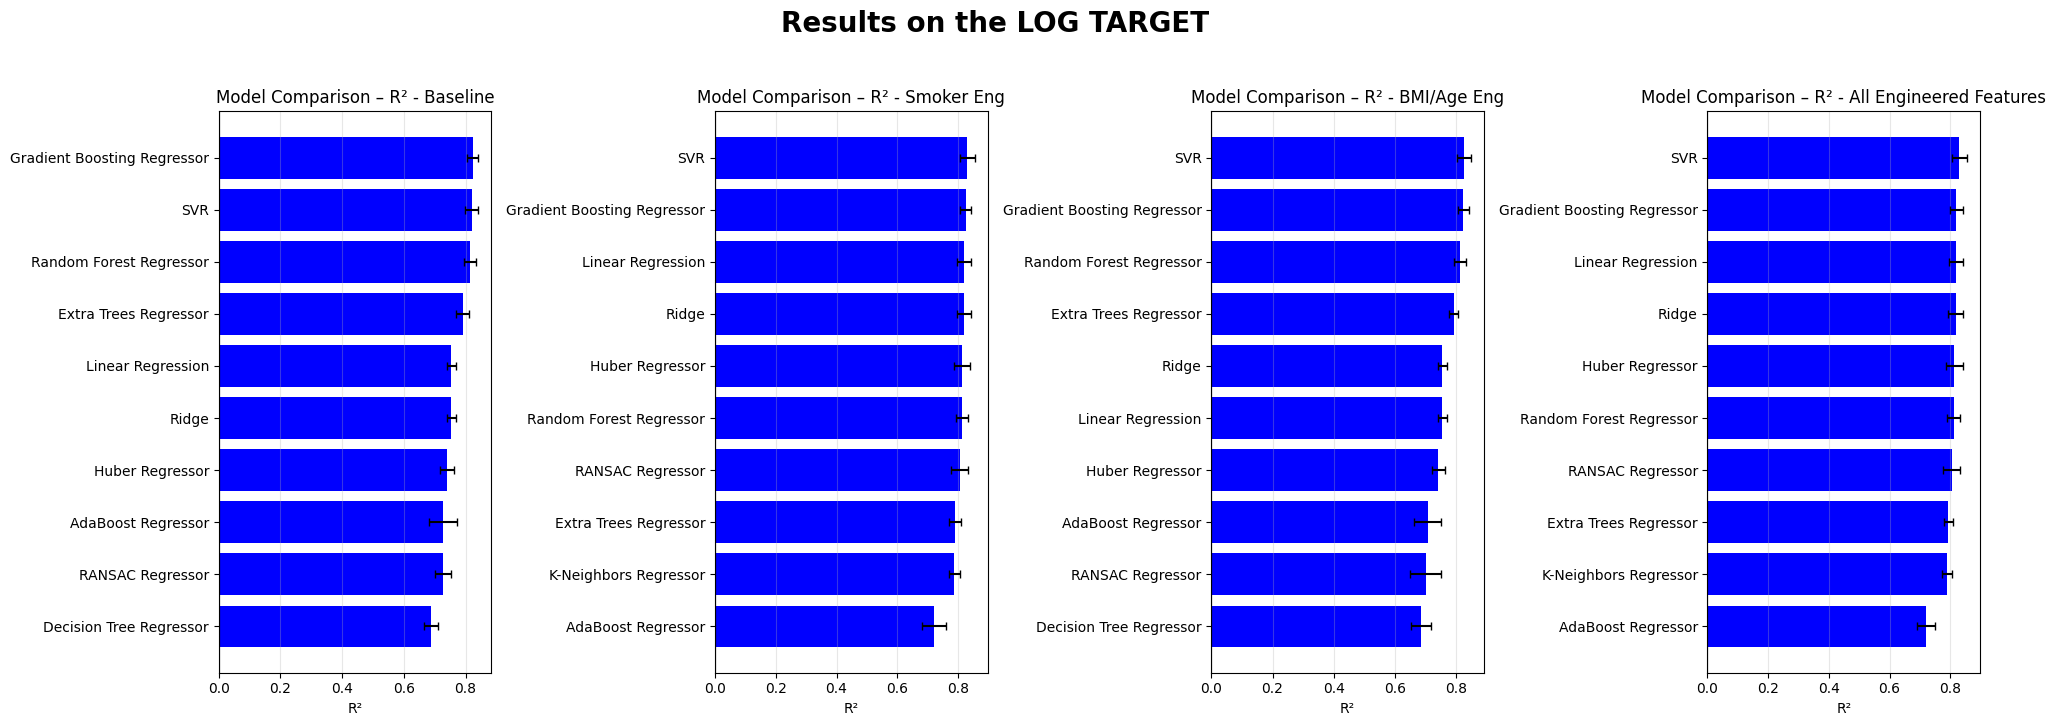

In [105]:
def plot_benchmarking_results(dfs: list, m: str, fe_sets: list, color):

    fig, axs = plt.subplots(1, 4, figsize=(20, 7))

    for i, (df, fe_set) in enumerate(zip(dfs, fe_sets)):
        # Top 10
        df = df.head(10)
        # --- R² ---
        axs[i].barh(df['Model'], df['R2_mean'],
                xerr=df['R2_std'], color=color, capsize=3)
        axs[i].axvline(0, color='black', linewidth=0.8)
        axs[i].set_xlabel('R²')
        axs[i].set_title(f'Model Comparison – R² - {fe_set}')
        axs[i].invert_yaxis()
        axs[i].grid(axis='x', alpha=0.3)

    plt.suptitle(f"Results on the {m}", fontsize=20, y=1.03, weight='bold')

    plt.tight_layout()
    plt.show()


raw_results = [baseline_results_raw, smoker_results_raw, bmi_age_results_raw, all_eng_results_raw]
log_results = [baseline_results_log, smoker_results_log, bmi_age_results_log, all_eng_results_log]

fe_sets = ['Baseline', 'Smoker Eng', 'BMI/Age Eng', 'All Engineered Features']

plot_benchmarking_results(dfs=raw_results, m='RAW TARGET', fe_sets=fe_sets, color='r')
plot_benchmarking_results(dfs=log_results, m='LOG TARGET', fe_sets=fe_sets, color='b')


#### -  Predicted‑vs‑actual scatter for top‑3 regressors

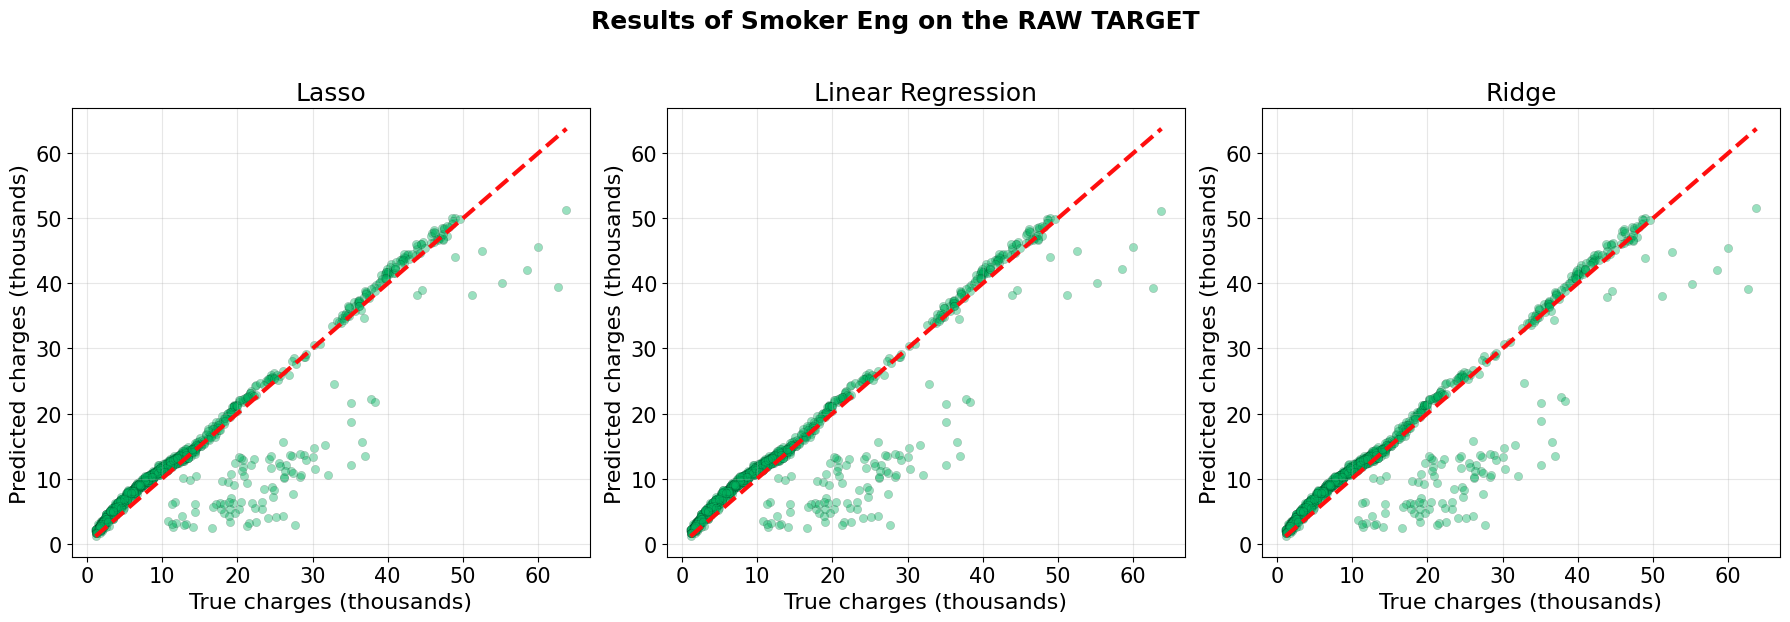

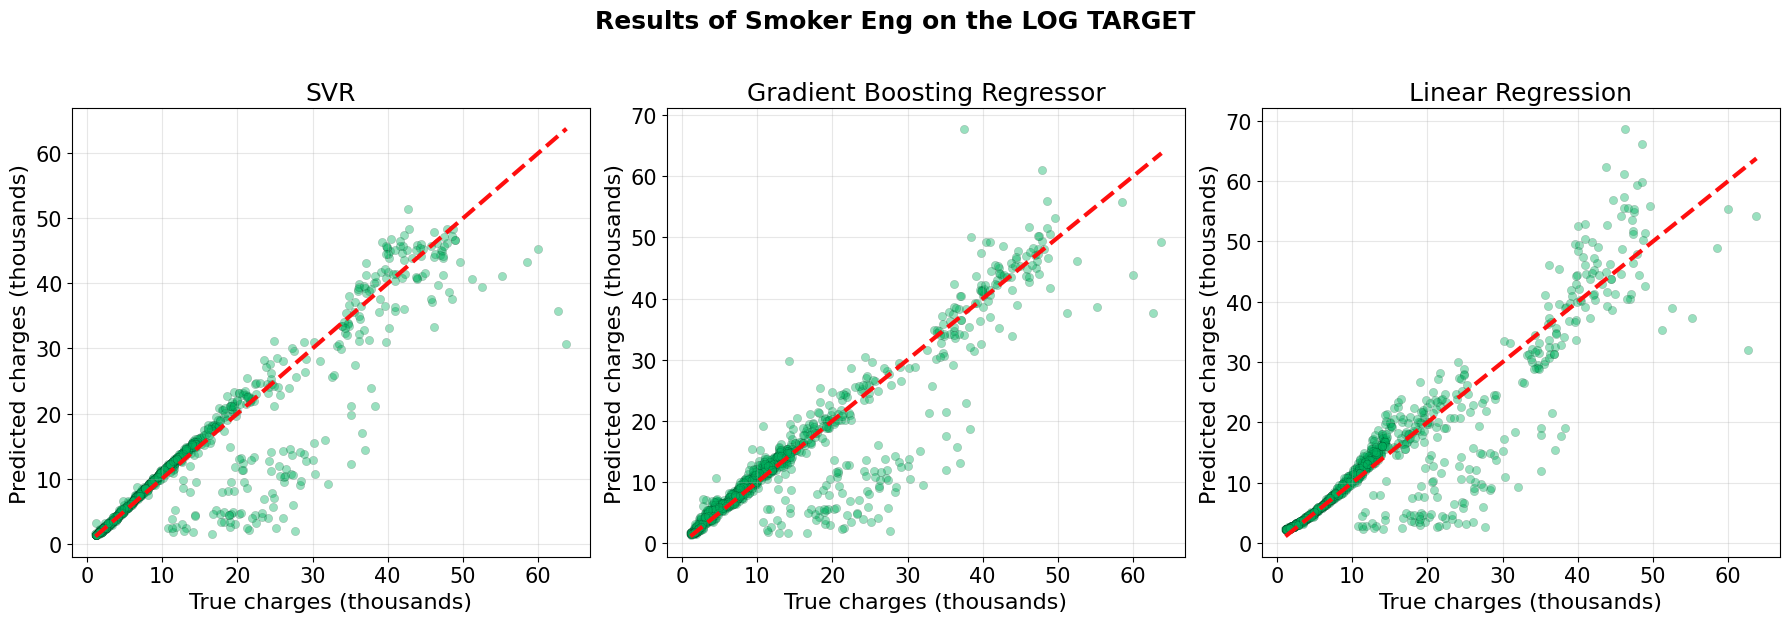

In [50]:
def plot_pred_vs_act(df, X, y, text, log_target=False):
    # Choose top 3 models by R2_mean (from results_df)
    top3_names = df['Model'].head(3).tolist()
    top3_models = {name: models[name] for name in top3_names}

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, (name, model) in zip(axes, top3_models.items()):
        reg = clone(model)
        y_cv_pred = cross_val_predict(reg, X, y, cv=5, n_jobs=-1)

        if log_target:
            y_plot = np.expm1(y)
            y_cv_pred = np.expm1(y_cv_pred)
        else:
            y_plot = y

        # Conversion
        y_plot_scaled = y_plot / 1000
        y_cv_pred_scaled = y_cv_pred / 1000

        ax.scatter(
            y_plot_scaled,
            y_cv_pred_scaled,
            alpha=0.4,
            edgecolors='k',
            color='#00b25f',
            linewidth=0.2
        )

        ax.plot(
            [y_plot_scaled.min(), y_plot_scaled.max()],
            [y_plot_scaled.min(), y_plot_scaled.max()],
            '--',
            color='#ff0e0e',
            lw=3
        )

        ax.set_xlabel('True charges (thousands)', fontsize=16)
        ax.set_ylabel('Predicted charges (thousands)', fontsize=16)
        ax.set_title(name, fontsize=18)
        ax.tick_params(axis='both', labelsize=15)
        ax.grid(alpha=0.3)

    plt.suptitle(f"Results of {text}", fontsize=18, y=1.03, fontweight='bold')

    plt.tight_layout()
    plt.show()


plot_pred_vs_act(smoker_results_raw, X_train_prep_smoker, y_train_raw, 'Smoker Eng on the RAW TARGET')
plot_pred_vs_act(smoker_results_log, X_train_prep_smoker, y_train_log, 'Smoker Eng on the LOG TARGET', log_target=True)


### 7) The final training on the full train set 


In [28]:

lasso_final = Lasso(random_state=RANDOM_STATE)

lasso_final.fit(
    X_train_prep_smoker,
    y_train_raw
)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [29]:

ridge_final = Ridge(random_state=RANDOM_STATE)

ridge_final.fit(
    X_train_prep_smoker,
    y_train_raw
)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


In [30]:

linear_final = LinearRegression()

linear_final.fit(
    X_train_prep_smoker,
    y_train_raw
)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 8) The final evaluation on the test set (For three trained models)

#### - Fundamental evaluation metrics

In [31]:
# Predict on the test set
y_pred_lasso = lasso_final.predict(
    X_test_prep_smoker
)

# Compute evaluation metrics (RMSE - MAE - R²)
r2_lasso = r2_score(y_test_raw, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y_test_raw, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_raw, y_pred_lasso)

print(f"Test set performance (Lasso):")
print(f"R²   : {r2_lasso:.4f}")
print(f"RMSE : {rmse_lasso:.2f}")
print(f"MAE  : {mae_lasso:.2f}")

Test set performance (Lasso):
R²   : 0.8821
RMSE : 4237.68
MAE  : 2304.42


In [32]:
# Predict on the test set
y_pred_ridge = ridge_final.predict(
    X_test_prep_smoker
)

# Compute evaluation metrics (RMSE - MAE - R²)
r2_ridge = r2_score(y_test_raw, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_test_raw, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_raw, y_pred_ridge)

print(f"Test set performance (ridge):")
print(f"R²   : {r2_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.2f}")
print(f"MAE  : {mae_ridge:.2f}")

Test set performance (ridge):
R²   : 0.8825
RMSE : 4230.34
MAE  : 2298.73


In [33]:
# Predict on the test set
y_pred_linear = linear_final.predict(
    X_test_prep_smoker
)

# Compute evaluation metrics (RMSE - MAE - R²)
r2_linear = r2_score(y_test_raw, y_pred_linear)
rmse_linear = root_mean_squared_error(y_test_raw, y_pred_linear)
mae_linear = mean_absolute_error(y_test_raw, y_pred_linear)

print(f"Test set performance (linear):")
print(f"R²   : {r2_linear:.4f}")
print(f"RMSE : {rmse_linear:.2f}")
print(f"MAE  : {mae_linear:.2f}")

Test set performance (linear):
R²   : 0.8821
RMSE : 4237.22
MAE  : 2304.80


#### - Plot the the final evaluation results

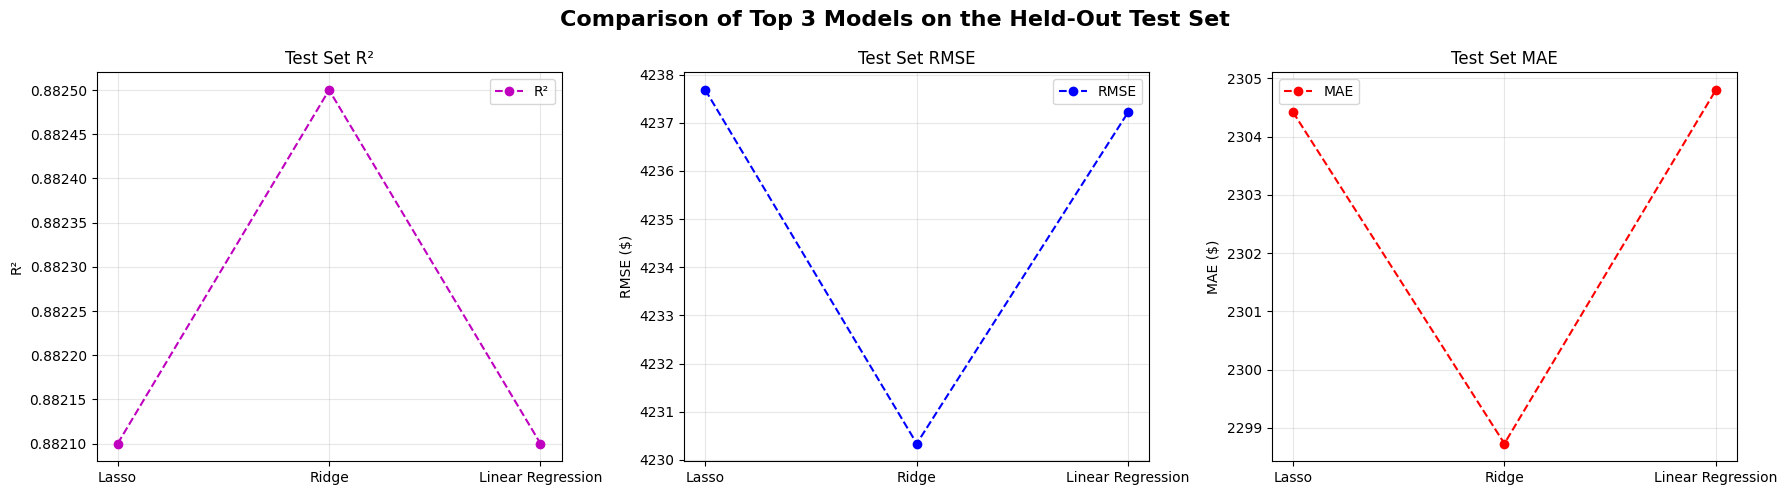

In [132]:

# Results
top3_results = pd.DataFrame({
    "Model": ["Lasso", "Ridge", "Linear Regression"],
    "R2": [0.8821, 0.8825, 0.8821],
    "RMSE": [4237.68, 4230.34, 4237.22],
    "MAE": [2304.42, 2298.73, 2304.80]
})

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# R²
ax1.plot(top3_results["Model"], top3_results["R2"], linestyle='--', marker='o', color='m', label='R²')
ax1.set_ylabel("R²")
ax1.set_title("Test Set R²")
ax1.grid(alpha=0.3)
ax1.legend()

# RMSE
ax2.plot(top3_results["Model"], top3_results["RMSE"], linestyle='--', marker='o', color='b', label='RMSE')
ax2.set_ylabel("RMSE ($)")
ax2.set_title("Test Set RMSE")
ax2.grid(alpha=0.3)
ax2.legend()

ax3.plot(top3_results["Model"], top3_results["MAE"], linestyle='--', marker='o', color='r', label='MAE')
ax3.set_ylabel("MAE ($)")
ax3.set_title("Test Set MAE")
ax3.grid(alpha=0.3)
ax3.legend()

plt.suptitle(
    "Comparison of Top 3 Models on the Held-Out Test Set",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

#### - Final Model Selection

Three top-performing models from cross-validation were evaluated on the
held-out test set:

| Model | Test R² | Test RMSE | Test MAE |
|---------|---------:|----------:|---------:|
| Lasso | 0.8821 | 4237.68 | 2304.42 |
| Ridge | **0.8825** | **4230.34** | **2298.73** |
| Linear Regression | 0.8821 | 4237.22 | 2304.80 |

#### Selected Final Model

**Ridge Regression** achieved the best overall performance on the unseen
test set, obtaining:

- **R² = 0.8825**
- **RMSE = 4230.34**
- **MAE = 2298.73**

Although the difference is small, Ridge Regression consistently produced
the strongest generalization performance and was therefore selected as the
final model for interpretation and analysis.

### 9) More visualization on the final model (Ridge Regression)

#### -  Plot predicted vs actual (test set)

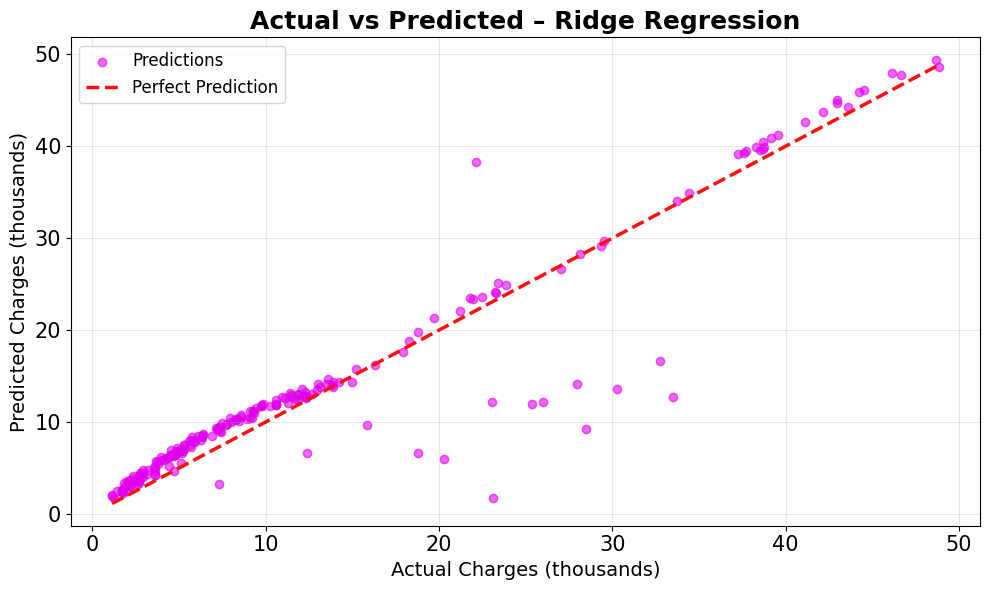

In [39]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_raw / 1000,
    y_pred_ridge / 1000,
    alpha=0.6,
    color="#e100ec",
    label='Predictions'
)

plt.plot(
    [y_test_raw.min() / 1000, y_test_raw.max() / 1000],
    [y_test_raw.min() / 1000, y_test_raw.max() / 1000],
    '--',
    color='#ff0e0e',
    lw=2.5,
    label='Perfect Prediction'
)

plt.xlabel('Actual Charges (thousands)', fontsize=14)
plt.ylabel('Predicted Charges (thousands)', fontsize=14)
plt.title('Actual vs Predicted – Ridge Regression', fontsize=18, fontweight='bold')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### - Residual plot

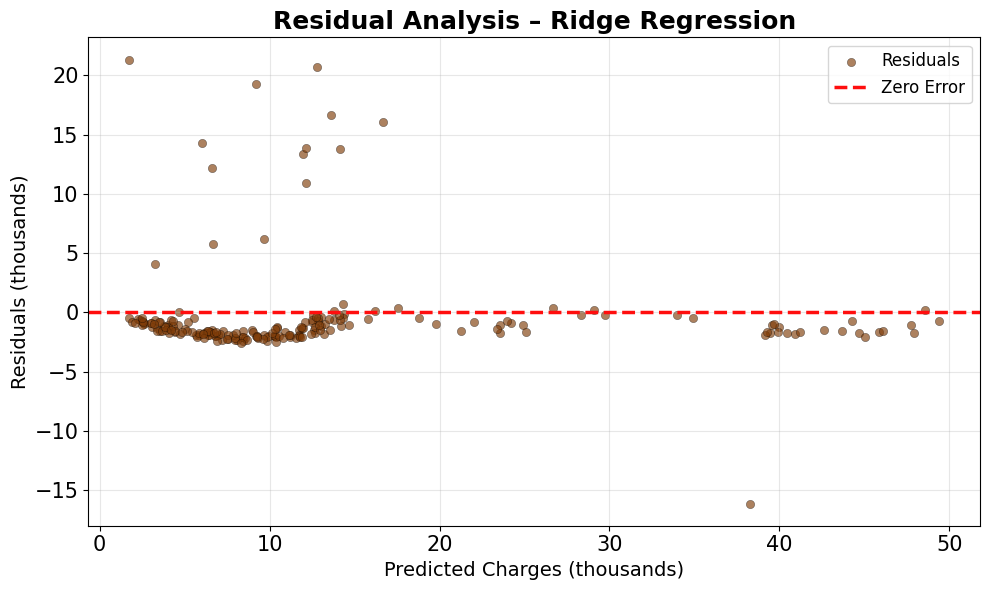

In [49]:
residuals = y_test_raw - y_pred_ridge

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_ridge / 1000,
    residuals / 1000,
    alpha=0.65,
    edgecolor='black',
    linewidth=0.3,
    color="#803d09",
    label='Residuals'
)

plt.axhline(
    y=0,
    color='#ff0e0e',
    linestyle='--',
    linewidth=2.5,
    label='Zero Error'
)

plt.xlabel('Predicted Charges (thousands)', fontsize=14)
plt.ylabel('Residuals (thousands)', fontsize=14)
plt.title('Residual Analysis – Ridge Regression', fontsize=18, fontweight='bold')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

#### - Coefficient (Feature) importance

In [41]:
feature_names = preprocessor_smoker.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_final.coef_
})

coef_df['AbsCoef'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('AbsCoef', ascending=True)

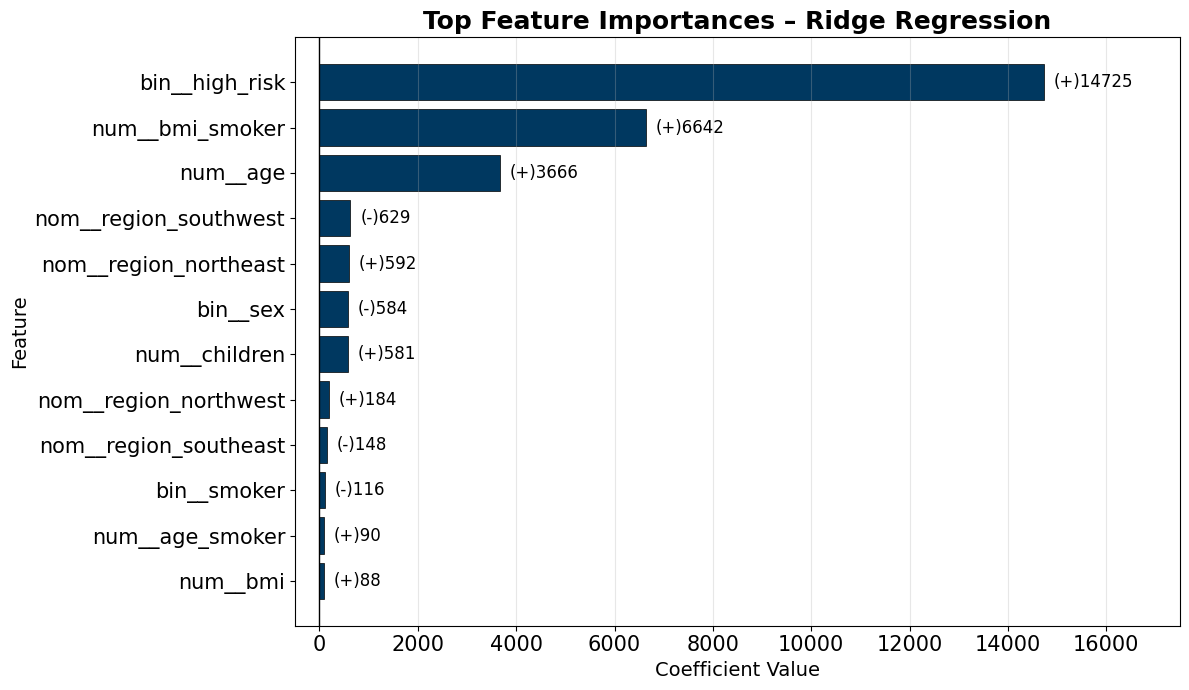

In [47]:
top_n = 12
plot_df = coef_df.head(top_n)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    plot_df['Feature'],
    plot_df['AbsCoef'],
    color="#003860",
    edgecolor='black',
    linewidth=0.5
)

plt.axvline(x=0, color='black', linewidth=1)

plt.xlabel('Coefficient Value', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Top Feature Importances – Ridge Regression', fontsize=18, fontweight='bold')
plt.xticks(np.arange(0, 18000, 2000), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis='x', alpha=0.3)
plt.xlim(-500, 17500)

for i, v in enumerate(plot_df['Coefficient']):

    if v >= 0:
        plt.text(v + 200, i, f'(+){v:.0f}', va='center', fontsize=12)

    else:
        plt.text(abs(v) + 200, i, f'(-){abs(v):.0f}', va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [166]:
#--------------------------------------------
# Save the model & preprocessing pipeline
#--------------------------------------------

joblib.dump(ridge_final, PROJECT_ROOT / "Models/Regression/ml_insurance_cost_model.joblib")
print("Model Saved: ml_insurance_cost_model.joblib")

Model Saved: ml_insurance_cost_model.joblib


## Conclusion – Medical Insurance Cost Regression

In this regression study, the objective was to predict **individual medical insurance charges** using demographic and health-related attributes from the Medical Cost Personal Dataset. The workflow followed a complete machine-learning pipeline including exploratory data analysis, preprocessing, feature engineering, cross-validation benchmarking, model selection, and final evaluation on an independent test set.

* **Baseline modeling performance** – A broad collection of regression algorithms was evaluated, including linear models, robust regressors, support vector regression, tree-based methods, and ensemble learners. Initial benchmarking demonstrated that both linear and ensemble approaches were capable of explaining a large proportion of the variance in insurance charges, indicating the presence of strong predictive relationships within the dataset.

* **Feature engineering experiments** – Multiple domain-inspired feature engineering strategies were investigated:

  * Smoking-related interaction features:

    * BMI × Smoker
    * Age × Smoker
    * High-Risk Indicator (Obesity × Smoker)

  * BMI and Age interaction features:

    * BMI × Age
    * Obesity Indicator
    * Severe Obesity Indicator

  * Combined feature-engineering scenario incorporating all engineered variables.

  Correlation analysis revealed that the smoking-related interaction variables exhibited the strongest relationship with insurance charges, particularly the BMI-Smoker interaction and High-Risk indicator. These engineered variables substantially improved model performance compared with the baseline feature set.

* **Target transformation experiments** – Both the original insurance charges and a logarithmically transformed target variable were evaluated. Although the log-transformed target produced improvements for several linear models during cross-validation, the highest overall predictive performance was obtained using the original target values, preserving direct interpretability of predictions in monetary units.

* **Model comparison and selection** – Systematic benchmarking across all feature-engineering scenarios showed that the strongest cross-validated performance was achieved using:

  * **Smoking-related engineered features**
  * **Original (raw) target variable**
  * **Lasso Regression**

  with a cross-validated performance of:

  * **R² ≈ 0.864**

  The results demonstrate that carefully designed domain-specific features can provide greater benefits than increasing model complexity alone.

* **Final test-set evaluation** – The three strongest linear models identified during benchmarking (Lasso, Ridge, and Linear Regression) were subsequently evaluated on the independent test set. Among them, **Ridge Regression** achieved the best overall performance:

  * **R² = 0.8825**
  * **RMSE = 4230**
  * **MAE = 2299**

  The similarity between cross-validation and test-set performance indicates strong generalization capability and minimal evidence of overfitting.

* **Model interpretation** – Feature importance analysis using Ridge coefficients confirmed that smoking-related variables dominated the prediction process. In particular:

  * High-Risk (Obesity × Smoker)
  * BMI × Smoker
  * Age

  emerged as the most influential predictors of insurance costs. These findings are consistent with established clinical and public-health knowledge regarding the economic impact of smoking and obesity on healthcare expenditure.

### Key Take-away

This study demonstrates how combining domain knowledge with systematic machine-learning methodology can substantially improve predictive performance.

The framework successfully:

* Produced reproducible and unbiased model evaluations through cross-validation.
* Demonstrated the effectiveness of clinically motivated feature engineering.
* Identified smoking-related interactions as the strongest drivers of insurance costs.
* Achieved strong predictive accuracy on unseen data.
* Balanced predictive performance with interpretability through the selection of a linear final model.

Overall, the results show that insurance charges can be predicted with high accuracy using a relatively small number of demographic and health-related variables when appropriate feature engineering techniques are applied. The workflow provides a practical and interpretable framework that can be extended to other healthcare cost prediction problems and medical tabular datasets.
